In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from scipy.sparse import issparse

Keys in file: ['barcode', 'coords', 'img']
Total patches: 3493
Patch shape:   (224, 224, 3)
Barcode sample: ["[b'AAACAAGTATCTCCCA-1']", "[b'AAACACCAATAACTGC-1']", "[b'AAACAGCTTTCAGAAG-1']", "[b'AAACAGGGTCTATATT-1']", "[b'AAACAGTGTTCCTGGG-1']"]


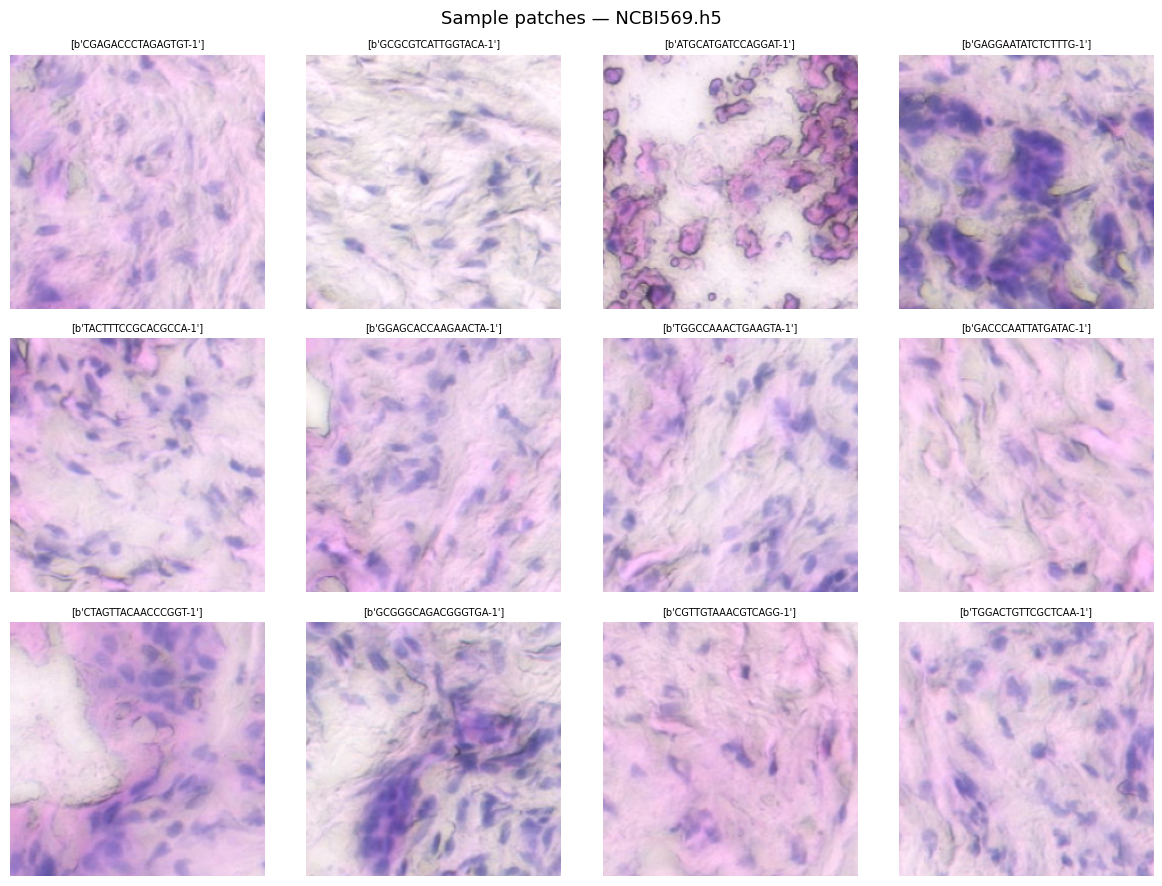

In [8]:
H5_PATH = "./hest_data/patches/NCBI569.h5"

with h5py.File(H5_PATH, "r") as f:
    print("Keys in file:", list(f.keys()))
    imgs     = f['img'][:]
    barcodes = f['barcode'][:]

barcodes = [b.decode('utf-8') if isinstance(b, bytes) else str(b) for b in barcodes]

print(f"Total patches: {imgs.shape[0]}")
print(f"Patch shape:   {imgs.shape[1:]}")
print(f"Barcode sample: {barcodes[:5]}")

# Plot 12 random patches
n_show  = 12
indices = np.random.choice(len(imgs), n_show, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(imgs[idx].astype(np.uint8))
    ax.set_title(barcodes[idx], fontsize=7)
    ax.axis('off')

plt.suptitle(f"Sample patches — {H5_PATH.split('/')[-1]}", fontsize=13)
plt.tight_layout()
plt.show()


In [21]:
H5AD_PATH = "./hest_data/st/NCBI569.h5ad"   # change to match above

adata = sc.read_h5ad(H5AD_PATH)
adata.var_names_make_unique()

print(f"Full matrix shape: {adata.shape}")
print(f"Spot barcodes sample: {list(adata.obs_names[:4])}")
print(f"Gene names sample:    {list(adata.var_names[:4])}\n")


mat = adata.X[:25, :25]
if issparse(mat):
    mat = mat.toarray()

df = pd.DataFrame(
    mat,
    index=list(adata.obs_names[:25]),
    columns=list(adata.var_names[:25])
)

print("raw count matrix (spots as rows, genes as columns):\n")
pd.set_option('display.float_format', '{:.1f}'.format)
print(df)


Full matrix shape: (3493, 20615)
Spot barcodes sample: ['AAACAAGTATCTCCCA-1', 'AAACACCAATAACTGC-1', 'AAACAGCTTTCAGAAG-1', 'AAACAGGGTCTATATT-1']
Gene names sample:    ['OR4F5', 'OR4F29', 'OR4F16', 'SAMD11']

raw count matrix (spots as rows, genes as columns):

                    OR4F5  OR4F29  OR4F16  SAMD11  NOC2L  KLHL17  PLEKHN1  PERM1  HES4  ISG15  AGRN  RNF223  C1orf159  TTLL10  TNFRSF18  TNFRSF4  SDF4  B3GALT6  C1QTNF12  UBE2J2  SCNN1D  ACAP3  PUSL1  INTS11  CPTP
AAACAAGTATCTCCCA-1    0.0     0.0     0.0     1.0    0.0     1.0      0.0    0.0   3.0    4.0   7.0     0.0       0.0     0.0       1.0      0.0   2.0      0.0       0.0     0.0     0.0    1.0    0.0     3.0   0.0
AAACACCAATAACTGC-1    0.0     0.0     0.0     0.0    1.0     0.0      0.0    0.0   2.0    1.0   5.0     0.0       1.0     0.0       0.0      0.0   4.0      0.0       0.0     0.0     0.0    0.0    0.0     0.0   0.0
AAACAGCTTTCAGAAG-1    0.0     0.0     0.0     0.0    1.0     0.0      0.0    0.0   1.0    1.0   1.